In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import helper_functions
import sklearn
from sklearn.metrics import mean_absolute_percentage_error

# Preparing the data
The data currently looks like this:
* machine name
* app information
* performance counters

We will first convert the data to an intermediate form as:
* source machine name
* app information (app, args, ranks)
* performance counters from source machine
* target machine name
* source machine metrics (RAJAPerfSuite benchmarking results)
* target machine metrics (RAJAPerfSuite benchmarking results)

Then, we will convert the data to the final form as:
* performance counters from source machine
* source machine metrics (RAJAPerfSuite benchmarking results)
* target machine metrics (RAJAPerfSuite benchmarking results)

Note that
* source machine indicates where the performance counters were gathered
* target machine indicates which machine's performance we're trying to predict
* NaN value is replaced with 0.0

## Reading in the application performance counter data

In [2]:
data_df = helper_functions.get_data()

### Information about the data (optional)

In [3]:
data_df['sid'] = range(1, len(data_df) + 1)
label_num_samples_per_mach, num_samples_per_mach = helper_functions.show_data_summary(data_df, 'machine')

Num samples =  3293
Num columns =  25

---------------------------------------------
Num apps =  14
    -  laghos 1003
    -  kripke.exe 630
    -  cosmoflow 37
    -  minigan 42
    -  miniqmc 43
    -  minitri 43
    -  comd 42
    -  deepcam 75
    -  sw4lite 65
    -  miniVite 713
    -  TestDfft 228
    -  amg 53
    -  XSBench 119
    -  miniFE.x 200

---------------------------------------------
Num machines =  4
    -  quartz 1231
    -  ruby 1062
    -  lassen 439
    -  corona 561
---------------------------------------------

---------------------sample 1------------------
 machine                                   quartz
app                                       laghos
args                     -p 1 -dim 2 -rs 1 -tf 3
ranks                                          1
duration                                    0.05
BR_INS                              2426000000.0
LD_INS                              3356000000.0
SR_INS                               968000000.0
TOT_INS         

## Dropping the samples that cannot be used to calculate relative performance 

In [4]:
# For calculating relative performance, we need at least a pair of observations from two different machines.
# If we have only a sample from an application with a specific string of arguments run by a specific number of ranks,
# we cannot calculate relative performance. Therefore, we remove those samples.
data_df = helper_functions.drop_unmatched_rows(data_df)
label_num_samples_per_mach, num_samples_per_mach = helper_functions.show_data_summary(data_df, 'machine')

Num samples =  2465
Num columns =  25

---------------------------------------------
Num apps =  8
    -  laghos 720
    -  kripke.exe 525
    -  sw4lite 37
    -  miniVite 713
    -  TestDfft 216
    -  amg 53
    -  XSBench 48
    -  miniFE.x 153

---------------------------------------------
Num machines =  4
    -  quartz 867
    -  ruby 820
    -  lassen 264
    -  corona 514
---------------------------------------------

---------------------sample 1------------------
 machine                                   quartz
app                                       laghos
args                     -p 1 -dim 2 -rs 2 -tf 3
ranks                                          1
duration                                  0.1833
BR_INS                              8200000000.0
LD_INS                             19434000000.0
SR_INS                              6256000000.0
TOT_INS                            59954000000.0
L1_LDM                               202000000.0
L1_STM                        

In [5]:
print(data_df['ranks'].unique())

[ 1 32]


## Filter out samples of Corona (optional)

In [6]:
data_df = data_df.loc[data_df['machine'] != 'corona']

## Filter out samples of the app 'sw4lite' (optional)

In [7]:
data_df = data_df.loc[data_df['app'] != 'sw4lite']

## Renaming **machine** row to **source machine**

In [8]:
# This is to prepare source and target machine combinations
machines = data_df['machine'].unique()
data_df = data_df.rename(columns={'machine': 'source machine'})

## Duplicating rows with multiple target machines

In [9]:
# If there exist N samples of a specific app+args+rank combination collected from N machines,
# the sample from each source machine is replicated to N target machines including itself.
# The new sample includes an extra column 'target machine'.
# Consequently, total NxN samples are created out of the original N samples.
data_df = helper_functions.create_machine_combinations(data_df)
label_num_samples_per_mach, num_samples_per_mach = helper_functions.show_data_summary(data_df, 'source machine')

Num samples =  4493
Num columns =  26

---------------------------------------------
Num apps =  7
    -  laghos 1614
    -  kripke.exe 840
    -  miniVite 1152
    -  TestDfft 468
    -  amg 109
    -  XSBench 96
    -  miniFE.x 214

---------------------------------------------
Num machines =  3
    -  quartz 1921
    -  ruby 1827
    -  lassen 745
---------------------------------------------

---------------------sample 1------------------
 source machine                            quartz
app                                       laghos
args                     -p 1 -dim 2 -rs 2 -tf 3
ranks                                          1
duration                                  0.1833
BR_INS                              8200000000.0
LD_INS                             19434000000.0
SR_INS                              6256000000.0
TOT_INS                            59954000000.0
L1_LDM                               202000000.0
L1_STM                               160000000.0
L2_LDM      

## Generating plots for data distribution (optional)

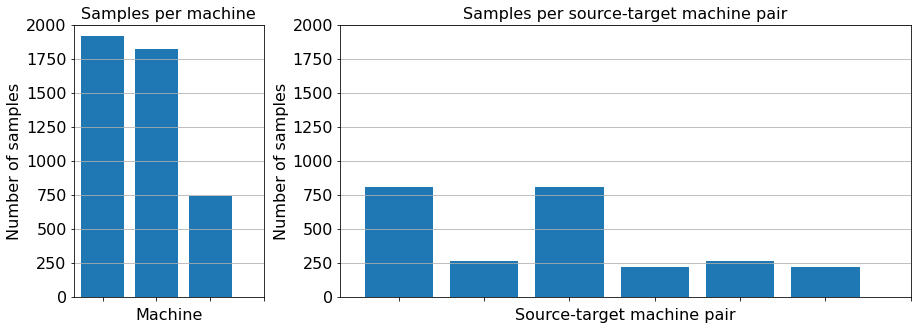

<Figure size 1080x360 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import textwrap
# Plot number of samples per target source machine pair

s_mach = data_df['source machine'].unique()
t_mach = data_df['target machine'].unique()
label_num_samples_per_pair = []
num_samples_per_pair = []
for s in s_mach:
    for t in t_mach:
        if t == s:
            continue
        else:
            label_num_samples_per_pair.append(s + ' to ' + t)
            num_samples_per_pair.append(len(data_df[(data_df['source machine'] == s) & (data_df['target machine'] == t)]))

helper_functions.set_plt_size()
plt.rcParams["figure.figsize"] = (15,5)
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [4, 12]})
# plt.ylim(0, 12)


ax0.bar(label_num_samples_per_mach, num_samples_per_mach)
ax1.bar(label_num_samples_per_pair, num_samples_per_pair)
# plt.bar(x, y)
y_max = 2000

ax1.title.set_text("Samples per source-target machine pair")
ax1.yaxis.set_label_text("Number of samples")
ax1.xaxis.set_label_text("Source-target machine pair")
ax1.set_xticks(np.arange(0, (len(label_num_samples_per_pair)+1)))
ax1.set_ylim([0, y_max])
ax1.grid(axis='y')

ax0.title.set_text("Samples per machine")
ax0.yaxis.set_label_text("Number of samples")
ax0.xaxis.set_label_text("Machine")
ax0.set_xticks(np.arange(0, (len(label_num_samples_per_mach)+1)))
ax0.set_ylim([0, y_max])
ax0.grid(axis='y')

# addlabels(x, y)
# axs[0].set_
helper_functions.wrap_labels(ax0, 10, 90)
helper_functions.wrap_labels(ax1, 10, 90)

plt.show()
# for i in range(len(x)):
#     print(x[i], y[i])  
plt.savefig("num_samples.png")

## Merge machine metric data

In [11]:
data_df = helper_functions.merge_benchmarks(data_df)
_,_ = helper_functions.show_data_summary(data_df, 'source machine')

Num samples =  4493
Num columns =  154

---------------------------------------------
Num apps =  7
    -  laghos 1614
    -  kripke.exe 840
    -  miniVite 1152
    -  TestDfft 468
    -  amg 109
    -  XSBench 96
    -  miniFE.x 214

---------------------------------------------
Num machines =  3
    -  quartz 1921
    -  ruby 1827
    -  lassen 745
---------------------------------------------

---------------------sample 1------------------
 source machine                                          quartz
app                                                     laghos
args                                   -p 1 -dim 2 -rs 2 -tf 3
ranks                                                        1
duration                                                0.1833
BR_INS                                            8200000000.0
LD_INS                                           19434000000.0
SR_INS                                            6256000000.0
TOT_INS                                       

## Calculating the relative performance

In [12]:
data_df = helper_functions.calc_relative_performances(data_df)
print('\n---------------------sample 1------------------\n', data_df.iloc[0,:])
print('\n---------------------sample 2------------------\n', data_df.iloc[1,:])


---------------------sample 1------------------
 source machine                                          quartz
app                                                     laghos
args                                   -p 1 -dim 2 -rs 2 -tf 3
ranks                                                        1
duration                                                0.1833
BR_INS                                            8200000000.0
LD_INS                                           19434000000.0
SR_INS                                            6256000000.0
TOT_INS                                          59954000000.0
L1_LDM                                             202000000.0
L1_STM                                             160000000.0
L2_LDM                                               6000000.0
L2_STM                                               4000000.0
FP_SINGLE                                            3259234.0
FP_DOUBLE                                        11407387387.0
ARITH

## (Optional) Get relative performance statistics

In [13]:
from collections import defaultdict
raw_dict = defaultdict(list)
sum_dict = defaultdict(lambda: [0.0, 0])
max_dict = defaultdict(lambda: float('-inf'))
min_dict = defaultdict(lambda: float('inf'))

with open('rel_raw0.txt', 'w') as f:
    for index, row in data_df.iterrows():
        m_s = row['source machine']
        m_t = row['target machine']
        # speedup
        rel = row['relative performance']
        cur = sum_dict[(m_s, m_t)];
        sum_dict[(m_s, m_t)] = (cur[0]+rel, cur[1]+1)

        cur_min = min_dict[(m_s, m_t)]
        if (cur_min > rel) :
            min_dict[(m_s, m_t)] = rel;

        cur_max = max_dict[(m_s, m_t)]
        if (cur_max < rel) :
            max_dict[(m_s, m_t)] = rel;
        raw_dict[(m_s, m_t)].append(rel)
        #print(' %s %s %.3f' % (m_s, m_t, rel), file=f)

with open('speedup_min.txt', 'w') as f:
    for (m_s, m_t), rel in min_dict.items():
        print(f"({m_s}, {m_t}) : {rel}", file=f)

with open('speedup_max.txt', 'w') as f:
    for (m_s, m_t), rel in max_dict.items():
        print(f"({m_s}, {m_t}) : {rel}", file=f)

with open('speedup_avg.txt', 'w') as f:
    for (m_s, m_t), rel in sum_dict.items():
        print(f"({m_s}, {m_t}) : {rel[1]} {rel[0]/rel[1]}", file=f)

with open('speedup_raw.txt', 'w') as f:
    for (m_s, m_t), rel in raw_dict.items():
        print(f"({m_s}, {m_t}) : {rel}", file=f)

In [14]:
uniq_df = data_df.drop_duplicates(subset=['app', 'args', 'ranks'], inplace=False)
with open('uniq_app_arg_rank.txt', 'w') as f:
    for index, row in uniq_df.iterrows():
        print(f"{row['app']}, {row['ranks']}, {row['args']}", file=f)

## Removing unneeded columns

In [15]:
# refined_df = data_df.copy()
refined_df = helper_functions.remove_unneeded_columns(data_df)
x_all, y_all = helper_functions.split_x_y(refined_df)

## XGBoost model training setup

In [16]:
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import make_scorer


# Intead of using 'mape' as the eval_metric pre-defined in xgboost,
# we define a custom mape evaluator to avoid the divide-by-zero issue
def xgb_mape(preds, dtrain):
   labels = dtrain.get_label()
   return('mape', -np.mean(np.abs((labels - preds) / (labels + 0.000001))))

n_estimators = 1500
max_depth = 6
eval_metric = xgb_mape

# define model evaluation method
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

## Test training setup (optional)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x_all, y_all, test_size = 0.20, random_state = 0)
print('num train samples: ', len(x_train))
print('num test samples: ', len(x_test))

model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth)
model.fit(x_train, y_train)
print('test MAPE: %.3f' % mean_absolute_percentage_error(y_test, model.predict(x_test)))
print('train MAPE: %.3f' % mean_absolute_percentage_error(y_train, model.predict(x_train)))

y_pred = model.predict(x_test)
y_test_arr = y_test.to_numpy()
mape = np.abs(y_test_arr - y_pred)/y_test_arr
mae = np.abs(y_test_arr - y_pred)

print('test MAPE (min, max, avg): %.3f %.3f %.3f' % (min(mape), max(mape), mape.mean()))
print('test MAE (min, max, avg): %.3f %.3f %.3f' % (min(mae), max(mae), mae.mean()))

print('Y_truth (avg std): %.3f %.3f' % (np.mean(y_test), np.std(y_test)))
print('Y_pred (avg std): %.3f %.3f' % (np.mean(y_pred), np.std(y_pred)))

#len(y_test[y_test == 0])

num train samples:  3594
num test samples:  899
test MAPE: 0.178
train MAPE: 0.005
test MAPE (min, max, avg): 0.000 16.232 0.178
test MAE (min, max, avg): 0.000 11.100 0.151
Y_truth (avg std): 1.429 2.798
Y_pred (avg std): 1.456 2.778


## Random Split

In [18]:
# mape_scorer = make_scorer(helper_functions.MAPE)
# mape_scorer = helper_functions.get_mape_scorer()
mape_scorer = make_scorer(sklearn.metrics.mean_absolute_percentage_error)
model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth, eval_metric=xgb_mape)

# evaluate model
scores = cross_val_score(model, x_all, y_all, scoring=mape_scorer, cv=cv, n_jobs=-1)

# force scores to be positive
random_mapes = np.absolute(scores)
print('Mean MAPE: %.3f (%.3f)' % (random_mapes.mean(), random_mapes.std()) )


model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth, eval_metric='mae')
scores = cross_val_score(model, x_all, y_all, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
random_maes = np.absolute(scores)

print('Mean MAE: %.3f (%.3f)' % (random_maes.mean(), random_maes.std()) )

Mean MAPE: 0.157 (0.018)
Mean MAE: 0.171 (0.027)


## Holding out one app for model testing while using the rest apps for training

In [19]:
model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth, eval_metric=xgb_mape)
app_removed_names, app_removed_mapes, app_removed_maes = helper_functions.test_any_app_removed(data_df, n_estimators, max_depth, xgb_mape)

laghos mape (avg, std): 1.529 0.000
kripke.exe mape (avg, std): 0.300 0.000
miniVite mape (avg, std): 0.502 0.000
TestDfft mape (avg, std): 1.156 0.000
amg mape (avg, std): 0.604 0.000
XSBench mape (avg, std): 1.003 0.000
miniFE.x mape (avg, std): 0.286 0.000
mean mape (avg, std, min, max): 0.768 0.436 0.286 1.529
mean mse (avg, std, min, max): 5.766 8.304 0.140 22.156
mean mae: (avg, std, min, max): 0.848 0.549 0.291 1.771


## Test Some Args/Runs Removed

In [20]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# import helper_functions

# n_estimators = 1250
# max_depth = 6
# data_df = helper_functions.do_all_setup()

args_removed_mapes, args_removed_maes = helper_functions.test_args_removed(data_df, n_estimators, max_depth)

print(args_removed_mapes)
print(min(args_removed_mapes), max(args_removed_mapes))
print(args_removed_maes)
print(min(args_removed_maes), max(args_removed_maes))

there are 814 total args
split sizes [899, 899, 899, 900, 896]
args length of 163
args length of 163
args length of 163
args length of 163
args length of 162
arg passed length 163
Num test samples:  3594
Num train samples:  899
0 of 5 has mape [0.13464184]
arg passed length 163
Num test samples:  3594
Num train samples:  899
1 of 5 has mape [0.15767508]
arg passed length 163
Num test samples:  3594
Num train samples:  899
2 of 5 has mape [0.13028098]
arg passed length 163
Num test samples:  3593
Num train samples:  900
3 of 5 has mape [0.16026711]
arg passed length 162
Num test samples:  3597
Num train samples:  896
4 of 5 has mape [0.14007071]
[array([0.13464184]), array([0.15767508]), array([0.13028098]), array([0.16026711]), array([0.14007071])]
[0.13028098] [0.16026711]
[array([0.15453739]), array([0.15051768]), array([0.13250313]), array([0.15823618]), array([0.15187127])]
[0.13250313] [0.15823618]


# Plot

In [21]:
print(len(app_removed_mapes))

for mapes in app_removed_mapes:
    print(min(mapes), max(mapes), np.mean(mapes), np.std(mapes))
    # print()
# np_temp = np.ndarray(app_removed_mapes)
# print(np.min(np_temp))

7
1.5286916778356368 1.5286916778356368 1.5286916778356368 0.0
0.29985918200224976 0.29985918200224976 0.29985918200224976 0.0
0.5024215695811238 0.5024215695811238 0.5024215695811238 0.0
1.1557429402078778 1.1557429402078778 1.1557429402078778 0.0
0.6036459892270332 0.6036459892270332 0.6036459892270332 0.0
1.002646128093031 1.002646128093031 1.002646128093031 0.0
0.2860917654845317 0.2860917654845317 0.2860917654845317 0.0


[1.5286916778356368, 0.29985918200224976, 0.5024215695811238, 1.1557429402078778, 0.6036459892270332, 1.002646128093031, 0.2860917654845317]


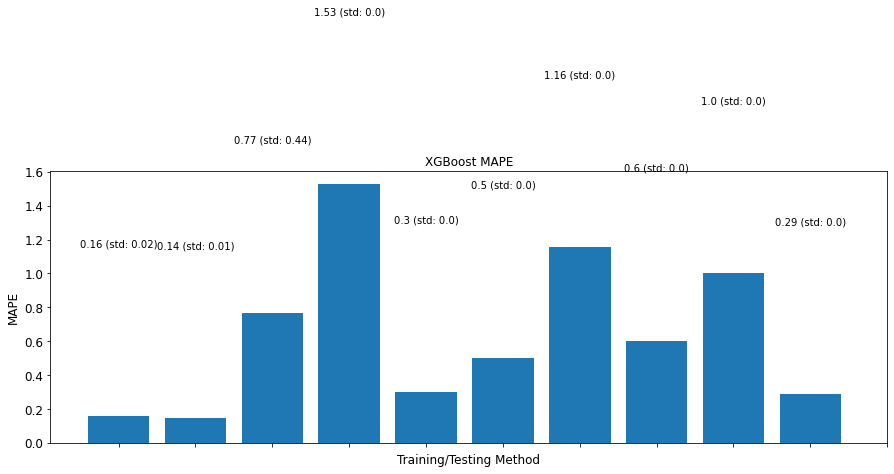

In [22]:
import matplotlib.pyplot as plt

def addlabels(x,y, y_err):
    for i in range(len(x)):
        plt.text(i,y[i] + 1, str(round(y[i], 2)) + ' (std: ' + str(round(y_err[i], 2)) + ')', ha='center')
        
# helper_functions.set_plt_size()
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots()


x = ['random split'] + ['1/5 of arguments removed'] + ['one app removed'] + (app_removed_names + ' removed').tolist()

# y = [0] + app_removed_mapes

avg_app_removed_mapes = []
std_app_removed_mapes = []
for i in range(len(app_removed_mapes)):
    avg_app_removed_mapes.append(np.mean(app_removed_mapes[i]))
    std_app_removed_mapes.append(np.std(app_removed_mapes[i]))
print(avg_app_removed_mapes)

y = [np.average(random_mapes)] + [np.average(args_removed_mapes)] + [np.average(avg_app_removed_mapes)] + avg_app_removed_mapes
errors = [np.std(random_mapes)] + [np.std(args_removed_mapes)] + [np.std(avg_app_removed_mapes)] + std_app_removed_mapes

# errors.append(np.std(random_mapes))
# errors[1] = np.std(args_removed_mapes))
# errors[2] = np.std(avg_app_removed_mapes)()
# errors = errors + std_app_removed_mapes



addlabels(x,y, errors)
# for i in range(3, 3 + len(std_app_removed_mapes)):
#     errors[i] = 0
# errors[] = 

ax.bar(x, y, ecolor='black', capsize=10)
# plt.bar(x, y)

ax.set_xticks(np.arange(0, (len(x)+1)))
plt.title("XGBoost MAPE")

plt.ylabel("MAPE")
plt.xlabel("Training/Testing Method")

# addlabels(x, y)

helper_functions.wrap_labels(ax, 10)

# plt.show()

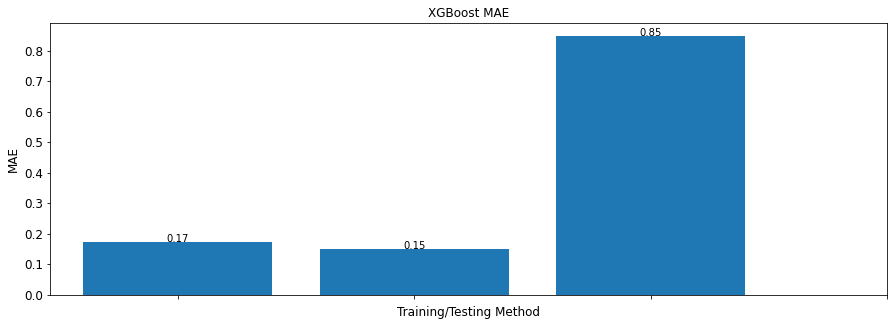

In [23]:
import matplotlib.pyplot as plt

def addlabels(x,y, y_err):
    for i in range(len(x)):
        plt.text(i,y[i] + .001, str(round(y[i], 2)), ha='center')

# helper_functions.set_plt_size()
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots()


x = ['random split'] + ['1/5 of arguments removed'] + ['one app removed']

# y = [0] + app_removed_mapes

# avg_app_removed_maes = []
# std_app_removed_maes = []
# for i in range(len(app_removed_mapes)):
#     avg_app_removed_maes.append(np.mean(app_removed_mapes[i]))
#     std_app_removed_maes.append(np.std(app_removed_mapes[i]))
# print(avg_app_removed_mapes)

y = [np.average(random_maes)] + [np.average(args_removed_maes)] + [np.average(app_removed_maes)]
# errors = [np.std(random_mapes)] + [np.std(args_removed_mapes)] + [np.std(avg_app_removed_mapes)] + std_app_removed_mapes
# errors.append(np.std(random_mapes))
# errors[1] = np.std(args_removed_mapes))
# errors[2] = np.std(avg_app_removed_mapes)()
# errors = errors + std_app_removed_mapes



addlabels(x,y, errors)

ax.bar(x, y, capsize=10)
# plt.bar(x, y)

ax.set_xticks(np.arange(0, (len(x)+1)))
plt.title("XGBoost MAE")

plt.ylabel("MAE")
plt.xlabel("Training/Testing Method")

# addlabels(x, y)

helper_functions.wrap_labels(ax, 10)

# plt.show()